# Introduction

This project demonstrates the migration of a Steam market analysis from R to Python. Beyond porting the original logic, I focused on optimizing data processing with Pandas and enhancing visualizations, while providing full documentation in English.

The database contains games released on Steam in 2019, the largest distribution platform for PC games. It includes information about these games from Steam, as well as additional data such as reviews and estimated sales figures from other sources like Steam and Steam Spy.

The database is available on Kaggle at this link: https://www.kaggle.com/datasets/nikdavis/steam-store-games?resource=download

## Variables

name - text: Game title<br>
release_date - text: Game release date<br>
developer - text: Name of the development studio<br>
categories - text: List of category tags<br>
total_reviews - number: Total number of reviews (positive + negative)<br>
average_playtime - number: Average playtime (in minutes)<br>
median_playtime - number: Median playtime (in minutes)<br>
owners - text later converted to number: Range of game owners, later the average of the range<br>
price - number: Game price in pounds sterling<br>

## Database processing

The packages I'll be using.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

Loading a database into a data frame and modifying it.

In [62]:
df = pd.read_csv("steam.csv")
df = df.drop(columns = ['appid', 'english', 'platforms', 'required_age', 'achievements', 'steamspy_tags', 'publisher', 'genres'])
df.head()

,name,release_date,developer,categories,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,Counter-Strike,2000-11-01,Valve,Multi-player;Online Multi-Player;Local Multi-P...,124534,3339,17612,317,10000000-20000000,7.19
1,Team Fortress Classic,1999-04-01,Valve,Multi-player;Online Multi-Player;Local Multi-P...,3318,633,277,62,5000000-10000000,3.99
2,Day of Defeat,2003-05-01,Valve,Multi-player;Valve Anti-Cheat enabled,3416,398,187,34,5000000-10000000,3.99
3,Deathmatch Classic,2001-06-01,Valve,Multi-player;Online Multi-Player;Local Multi-P...,1273,267,258,184,5000000-10000000,3.99
4,Half-Life: Opposing Force,1999-11-01,Gearbox Software,Single-player;Multi-player;Valve Anti-Cheat en...,5250,288,624,415,5000000-10000000,3.99


In [63]:
df.tail()

,name,release_date,developer,categories,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
27070,Room of Pandora,2019-04-24,SHEN JIAWEI,Single-player;Steam Achievements,3,0,0,0,0-20000,2.09
27071,Cyber Gun,2019-04-23,Semyon Maximov,Single-player,8,1,0,0,0-20000,1.69
27072,Super Star Blast,2019-04-24,EntwicklerX,Single-player;Multi-player;Co-op;Shared/Split ...,0,1,0,0,0-20000,3.99
27073,New Yankee 7: Deer Hunters,2019-04-17,Yustas Game Studio,Single-player;Steam Cloud,2,0,0,0,0-20000,5.19
27074,Rune Lord,2019-04-24,Adept Studios GD,Single-player;Steam Cloud,4,0,0,0,0-20000,5.19


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              27075 non-null  str    
 1   release_date      27075 non-null  str    
 2   developer         27074 non-null  str    
 3   categories        27075 non-null  str    
 4   positive_ratings  27075 non-null  int64  
 5   negative_ratings  27075 non-null  int64  
 6   average_playtime  27075 non-null  int64  
 7   median_playtime   27075 non-null  int64  
 8   owners            27075 non-null  str    
 9   price             27075 non-null  float64
dtypes: float64(1), int64(4), str(5)
memory usage: 2.1 MB


To streamline the analysis, I will calculate the percentage of positive ratings for each game. I will also convert the median playtime from minutes to hours for better readability. Furthermore, the 'owners' column, originally provided as ranges, will be transformed into numerical values by taking the midpoint of each range.

In [65]:
temp_owners_split = df['owners'].str.split('-', expand = True)
df['owners'] = (temp_owners_split[0].astype(float) + temp_owners_split[1].astype(float)) / 2
df['owners'] = df['owners'].astype(int)

In [66]:
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']

positive_percent = (df['positive_ratings'] / (df['positive_ratings'] + df['negative_ratings'])) * 100
positive_percent = round(positive_percent, 2)
df['positive_percent_rating'] = positive_percent
df = df.drop(columns = ['positive_ratings', 'negative_ratings'])


In [67]:
df['average_playtime'] = round(df['average_playtime'] / 60, 2)
df['median_playtime'] = round(df['median_playtime'] / 60, 2)

To ensure the reliability of the analysis, I will filter out games with an insufficient number of reviews. To determine a fair threshold, I will examine the median review counts within different owner segments.

In [68]:
ratings_median = df.groupby('owners')['total_ratings'].median()

print(ratings_median)


owners
10000             17.0
35000            133.0
75000            298.0
150000           635.5
350000          1365.0
750000          4290.0
1500000        10586.5
3500000        21421.0
7500000        46020.0
15000000      106018.0
35000000      324056.0
75000000     2014988.5
150000000    1005586.0
Name: total_ratings, dtype: float64


As observed, the median number of reviews for the 0 - 20,000 owner bracket is only 17. This is a very low figure for a meaningful analysis, so I have decided to exclude games with 20,000 or fewer owners from the dataset.

In [69]:
df = df[df['owners'] > 20000]

# Analisis

### Owners to positive raiting correlation

This section explores the relationship between user sentiment and market success. Unlike other industries, the gaming market is driven by a highly engaged and vocal consumer base. Players often exhibit 'paradoxical' behavior, where extensive playtime does not always translate into a positive rating especially when reacting to specific developer decisions or patches.

In [70]:
own_rat_spearman_corr = df['owners'].corr(df['positive_percent_rating'])
print(own_rat_spearman_corr)

0.06807784924305979


The calculated correlation coefficient of 0.068 indicates a negligible positive relationship between positive ratings and owner counts. This statistically confirms that commercial success on Steam does not necessarily guarantee higher user satisfaction. The data highlights a significant number of 'hidden gems' high-quality titles that maintain exceptional ratings despite limited sales, often due to niche appeal or a lack of mainstream visibility.

### Positive rating to playtime correlation

Moving forward, it is essential to examine the relationship between player engagement measured by playtime and user sentiment. Does a higher investment of time naturally lead to more favorable reviews, or does it make players more critical?

In [71]:
rat_time_spearman_corr = df['positive_percent_rating'].corr(df['average_playtime'])
print(rat_time_spearman_corr)

0.036645292133674366


Once again, the correlation is negligible. To explore this from a different perspective, I will apply a categorical approach by segmenting the games into two groups: 'Top Rated' (positive ratings >= 90%) and 'Others'. This binary classification will help determine if high engagement is more prevalent among the top-rated titles.

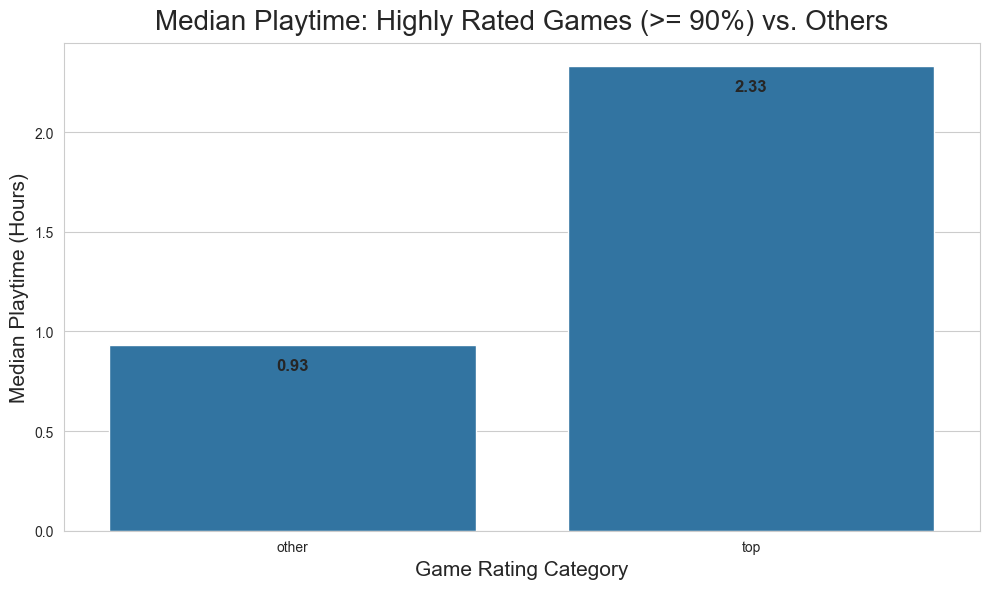

In [72]:
df['top_rated'] = np.where(df['positive_percent_rating'] >= 90, 'top', 'other')
ratings_stats = df.groupby('top_rated')['average_playtime'].median().reset_index()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data = ratings_stats, x = 'top_rated', y = 'average_playtime')
ax.bar_label(ax.containers[0], fmt = '%.2f', padding = -20, fontsize = 12, fontweight = 'bold', label_type = 'edge')
plt.title('Median Playtime: Highly Rated Games (>= 90%) vs. Others', fontsize = 20, pad = 10)
plt.xlabel('Game Rating Category', fontsize = 15)
plt.ylabel('Median Playtime (Hours)', fontsize = 15)
plt.tight_layout()
plt.show()

At this stage, a significant disparity becomes evident. In games with a positive rating of 90% or higher, players spend on average 2.5 times more time compared to other titles. While a broad linear correlation between ratings and sales is absent, a strong link emerges when focusing specifically on top-rated 'hits.' This suggests that extreme quality is a major driver of long-term engagement and market success.

### Price and quantity purchased

Are players more inclined to purchase games at lower price points? I will segment the library into four price brackets to determine which category generates the highest volume of owners.

In [73]:
price_q1 = df.loc[df['price'] > 0, 'price'].quantile(0.25)
price_median = df.loc[df['price'] > 0, 'price'].median()
price_AAA = df.loc[df['price'] > 0, 'price'].quantile(0.98)

print("Q1:", price_q1)
print("Median:", price_median)
print("AAA: ", price_AAA) #percentage of AAA games (games with a budget of over $100 million). In 2019, In 2019, AAA games accounted for about 2% of the games on Steam

Q1: 3.19
Median: 6.99
AAA:  34.99


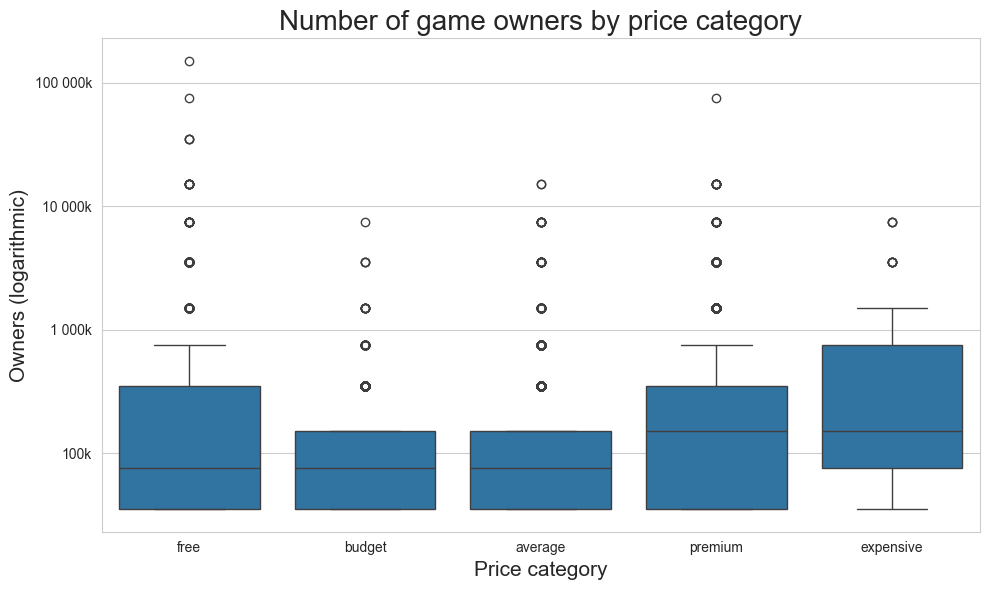

In [81]:
bins =[-1, 0, price_q1, price_median, price_AAA, float('inf')]
labels = ['free', 'budget', 'average', 'premium', 'expensive']
df['price_category'] = pd.cut(df['price'], bins = bins, labels = labels)

plt.figure(figsize = (10, 6))
ax = sns.boxplot(
    data = df,
    x = 'price_category',
    y = 'owners'
)
ax.set_yscale("log")
plt.title('Number of game owners by price category', fontsize = 20)
plt.xlabel('Price category', fontsize = 15)
plt.ylabel('Owners (logarithmic)', fontsize = 15)

def thousands_formatter(x, pos):
    return f'{int(x/1000):,}k'.replace(',', ' ')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()


Quality and community ratings have a greater impact on market success than pricing strategy. Although there are massive hits in the free-to-play segment, these are often statistical outliers. Interestingly, AAA titles have the highest minimum sales figures. This may suggest that games with the largest budgets have the funds for marketing, which leads to more people buying the games.